# Background Removal with BiRefNet

This notebook loads the state-of-the-art **BiRefNet** model for background removal (dichotomous image segmentation) and runs it on our test image.

In [11]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoModelForImageSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Load the Model
We load the model using `AutoModelForImageSegmentation`. Since BiRefNet uses custom hub code, we must set `trust_remote_code=True`.

In [12]:
print("Loading BiRefNet model...")
model = AutoModelForImageSegmentation.from_pretrained("ZhengPeng7/BiRefNet", trust_remote_code=True)
model.to(device)
model.eval()
print("Model loaded successfully!")

Loading BiRefNet model...
Model loaded successfully!


## Process and Extract Background
We resize the image to `1024x1024` (BiRefNet standard resolution) and normalize it. After running inference, we extract the mask and apply it as the alpha channel.

In [13]:
def extract_object(image_path):
    # 1. Load Image
    input_image = Image.open(image_path).convert("RGB")
    original_size = input_image.size

    # 2. Preprocess
    transform = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    input_tensor = transform(input_image).unsqueeze(0).to(device)

    # 3. Predict
    with torch.no_grad():
        preds = model(input_tensor)[-1].sigmoid().cpu() # Get the last output and apply sigmoid

    # 4. Post-process mask
    mask = transforms.ToPILImage()(preds[0])
    mask = mask.resize(original_size)

    # 5. Apply Mask to Original Image
    result_image = input_image.copy()
    result_image.putalpha(mask)
    return result_image, mask

print("Helper function defined.")

Helper function defined.


## Run Inference and Save Output
We run the pipeline on `test.png` and save the result as `output.png`.

Saved output to output.png


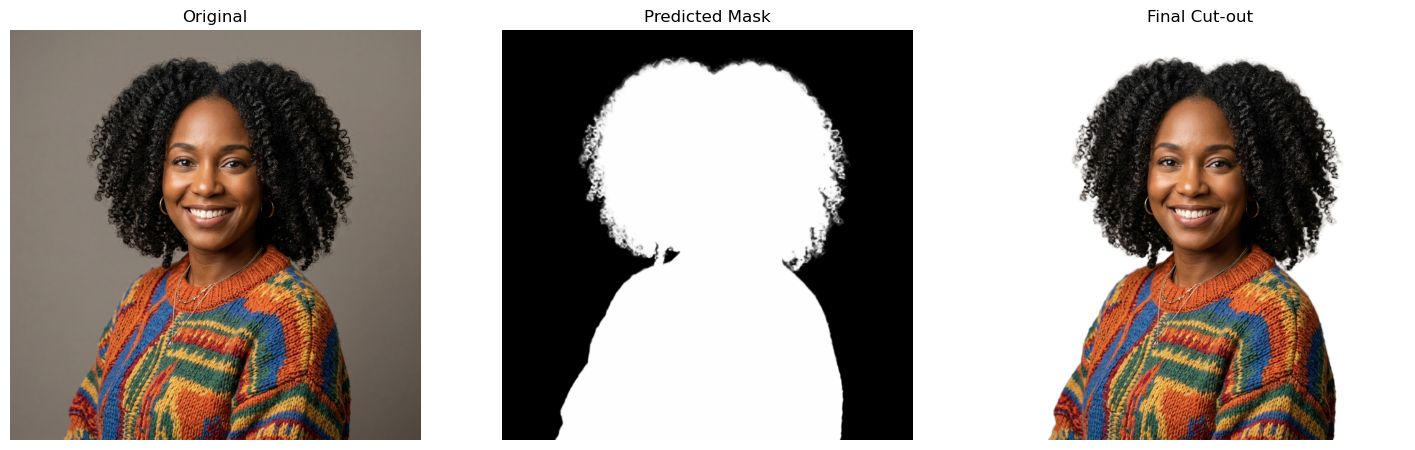

In [14]:
image_path = "test.png"
result_image, mask_image = extract_object(image_path)

# Save the transparent image
result_image.save("output.png")
print("Saved output to output.png")

# Display results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(Image.open(image_path))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(mask_image, cmap='gray')
ax[1].set_title("Predicted Mask")
ax[1].axis("off")

ax[2].imshow(result_image)
ax[2].set_title("Final Cut-out")
ax[2].axis("off")

plt.show()

## Phase 2: Confidence-Guided Matting with BEN2

Now we'll load and use **BEN2** (Background Eraser Network 2). BEN2 uses **Confidence Guided Matting (CGM)** to focus its refinement on pixels where it has lower classification confidence (like hair or edges).

In [15]:
# Note: This requires the ben2 library to be installed:
# pip install -e "git+https://github.com/PramaLLC/BEN2.git#egg=ben2"

from ben2 import BEN_Base

print("Loading BEN2 model...")
ben_model = BEN_Base.from_pretrained("PramaLLC/BEN2")
ben_model.to(device)
ben_model.eval()
print("BEN2 model loaded successfully!")

Loading BEN2 model...


BEN2 model loaded successfully!


### Run Inference with BEN2
We run the model on `test.png`. Setting `refine_foreground=True` will improve edge details (like hair) at a small cost to execution time.

In [16]:
test_image = Image.open(image_path)

print("Running BEN2 inference...")
ben_result = ben_model.inference(test_image, refine_foreground=True)

# Save output
ben_result.save("output_ben.png")
print("Saved BEN2 output to output_ben.png")

Running BEN2 inference...
Saved BEN2 output to output_ben.png


### Model Comparison
Let's compare the original image, the BiRefNet cutout, and the BEN2 cutout side-by-side.

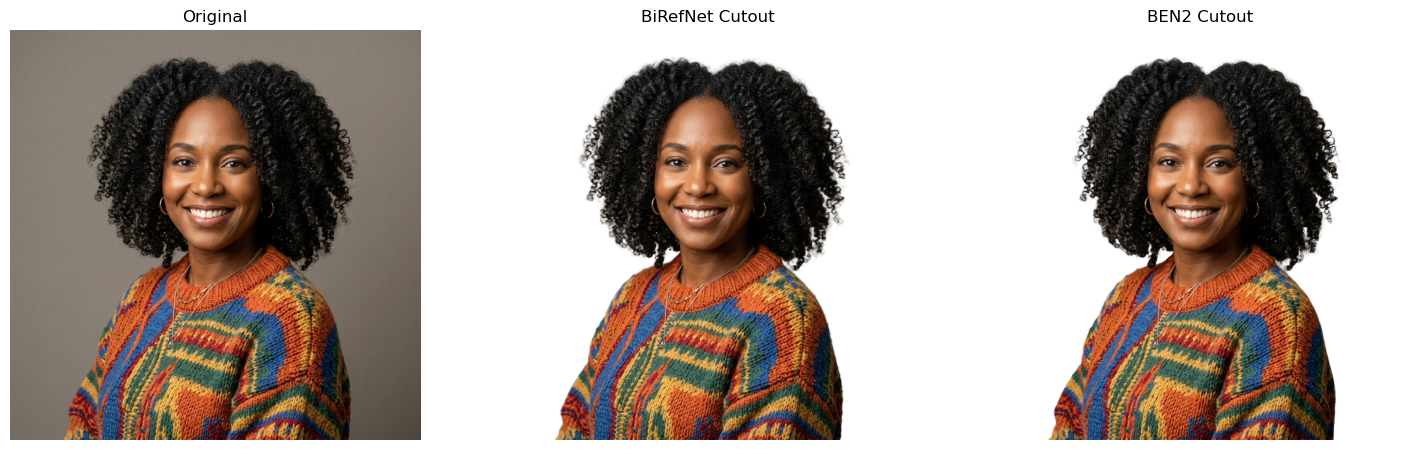

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(Image.open(image_path))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(result_image)
ax[1].set_title("BiRefNet Cutout")
ax[1].axis("off")

ax[2].imshow(ben_result)
ax[2].set_title("BEN2 Cutout")
ax[2].axis("off")

plt.show()

Results differ: 34150470/48000000 pixels are different (71.15%)
Saved BiRefNet result to output/img1 (1)_birefnet.png
Saved BEN2 result to output/img1 (1)_ben2.png


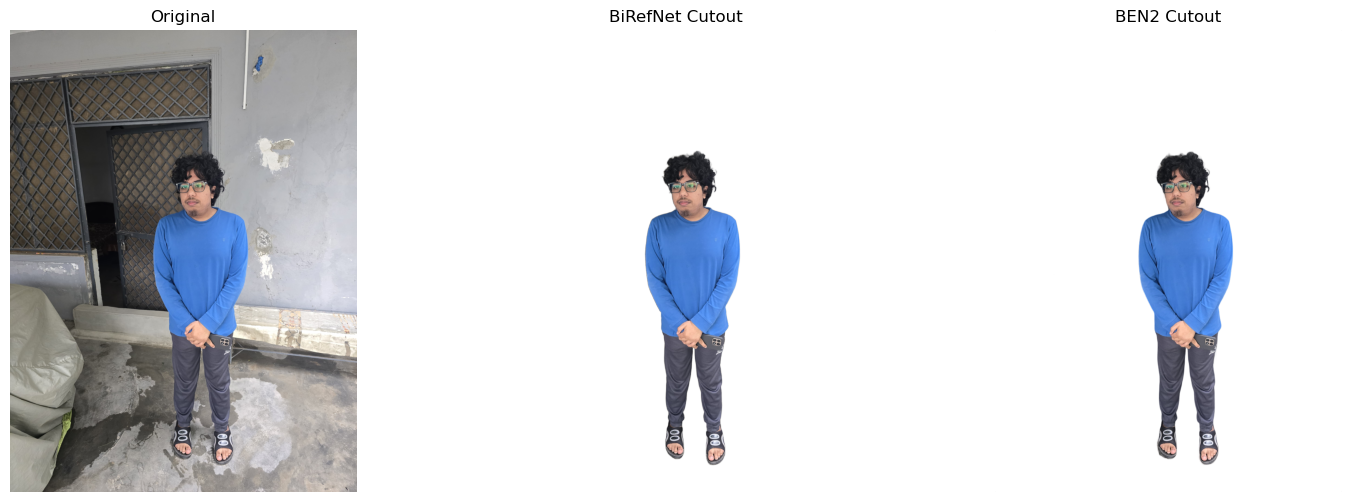

Results differ: 31413848/48000000 pixels are different (65.45%)
Saved BiRefNet result to output/img1 (2)_birefnet.png
Saved BEN2 result to output/img1 (2)_ben2.png


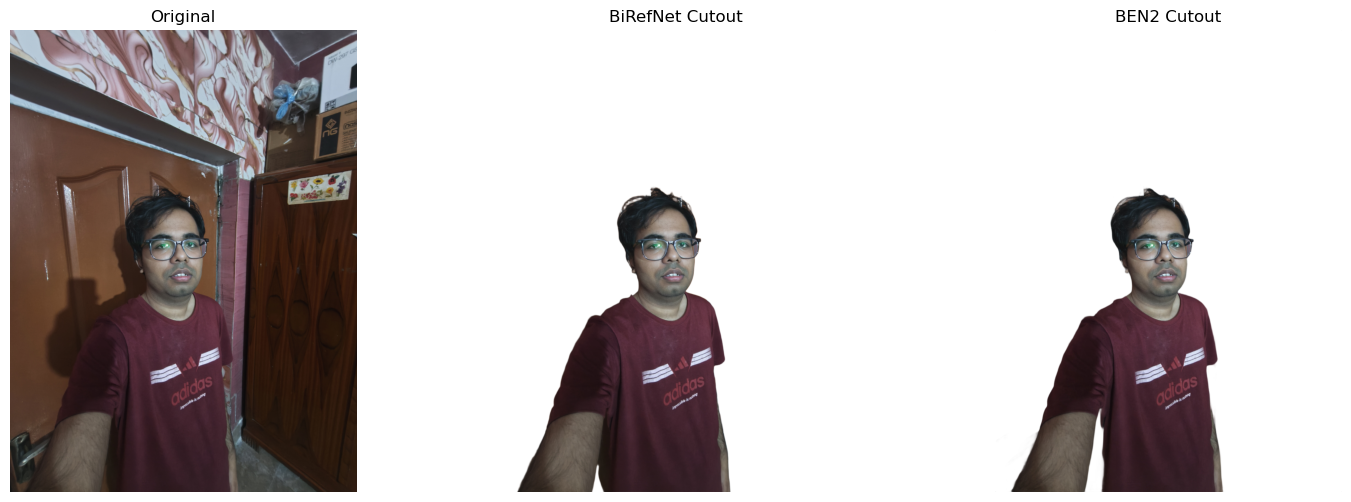

In [20]:
import os
import numpy as np

def test_image(path):
    # Create output directory if it doesn't exist
    os.makedirs("output", exist_ok=True)
    
    # Get base filename without extension
    base_name = os.path.splitext(os.path.basename(path))[0]
    
    # 1. Run BiRefNet Inference
    birefnet_result, birefnet_mask = extract_object(path)
    
    # 2. Run BEN2 Inference
    test_img = Image.open(path)
    ben_result = ben_model.inference(test_img, refine_foreground=True)
    
    # 3. Debug: Check if results are different
    birefnet_array = np.array(birefnet_result)
    ben_array = np.array(ben_result)
    
    if np.array_equal(birefnet_array, ben_array):
        print("WARNING: BiRefNet and BEN2 results are IDENTICAL!")
    else:
        diff_pixels = np.sum(birefnet_array != ben_array)
        total_pixels = birefnet_array.size
        print(f"Results differ: {diff_pixels}/{total_pixels} pixels are different ({100*diff_pixels/total_pixels:.2f}%)")
    
    # 4. Save outputs
    birefnet_output_path = f"output/{base_name}_birefnet.png"
    ben_output_path = f"output/{base_name}_ben2.png"
    
    birefnet_result.save(birefnet_output_path)
    ben_result.save(ben_output_path)
    
    print(f"Saved BiRefNet result to {birefnet_output_path}")
    print(f"Saved BEN2 result to {ben_output_path}")
    
    # 5. Plot Comparison Side-by-Side
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(test_img)
    ax[0].set_title("Original")
    ax[0].axis("off")
    
    ax[1].imshow(birefnet_result)
    ax[1].set_title("BiRefNet Cutout")
    ax[1].axis("off")
    
    ax[2].imshow(ben_result)
    ax[2].set_title("BEN2 Cutout")
    ax[2].axis("off")
    
    plt.show()
    
    return birefnet_result, ben_result
birres,ben_result =  test_image(path='img1 (1).jpg')
birres2,ben_result2= test_image(path='img1 (2).jpg')